### This notebook is intended to study and analyse the effect of outliers during scaling.

In [7]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# here i have created my own dataframe
df = pd.DataFrame(
    {"age":[20,23,25,19,29,27,45,32,78,64],
    "income":[30000,40000,56000,18000,32000,26000,67000,120000,43000,55000],
    "purchased":["yes","no","yes","no","yes","no","yes","yes","no","yes"]
    })
df

,age,income,purchased
0,20,30000,yes
1,23,40000,no
2,25,56000,yes
3,19,18000,no
4,29,32000,yes
5,27,26000,no
6,45,67000,yes
7,32,120000,yes
8,78,43000,no
9,64,55000,yes


In [75]:
myData = df[["age","income"]]
myData.columns

Index(['age', 'income'], dtype='object')

In [ ]:
#scale the data uisng z-score normalization using class StanndardScaler
scaler =StandardScaler()
myData_scaled = scaler.fit_transform(myData) # we are fitting and transforming in one step
myData_scaled = pd.DataFrame(myData_scaled, columns=myData.columns)

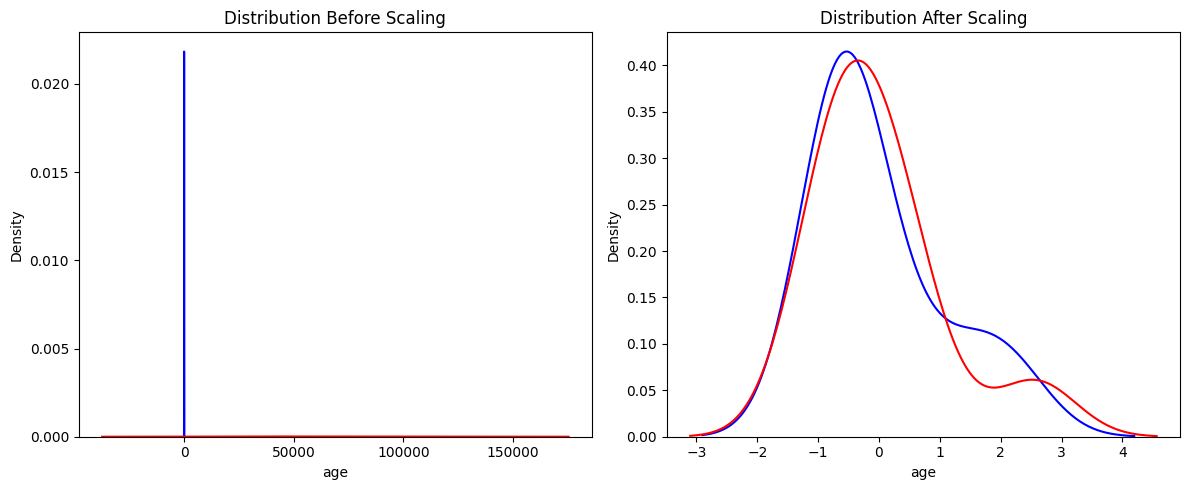

In [81]:
fig,(ax1,ax2)= plt.subplots(1,2,figsize=(12,5)) # this line is just to display plots side by side 

# left plot
ax1.set_title("Distribution Before Scaling")
sns.kdeplot(myData,x="age",color="blue",fill=False, ax=ax1)
sns.kdeplot(myData,x="income",color="red",fill=False,ax=ax1)


# right plot
ax2.set_title("Distribution After Scaling")
sns.kdeplot(myData_scaled,x="age",color="blue",fill=False,ax=ax2)
sns.kdeplot(myData_scaled,x="income",color="red",fill=False,ax=ax2)



plt.tight_layout()
plt.show()

In [ ]:
# we can also scale the data using normalization (MinMax normalization)


## now, Lets try that in a real dataset

In [38]:
ads = pd.read_csv("Social_Network_Ads.csv")
ads.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [45]:
scaler = StandardScaler()
ads_scaled = scaler.fit_transform(ads[["Age","EstimatedSalary"]])
ads_scaled = pd.DataFrame(ads_scaled,columns=["Age","EstimatedSalary"])
ads_scaled

,Age,EstimatedSalary
0,-1.781797,-1.490046
1,-0.253587,-1.460681
2,-1.113206,-0.785290
3,-1.017692,-0.374182
4,-1.781797,0.183751
...,...,...
395,0.797057,-0.844019
396,1.274623,-1.372587
397,1.179110,-1.460681
398,-0.158074,-1.078938


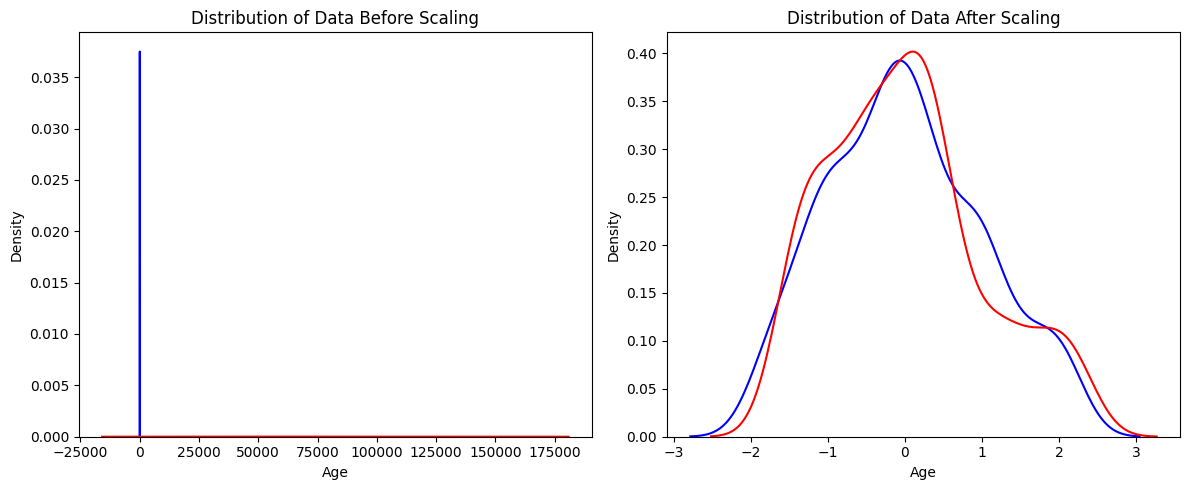

In [82]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

#left plot
sns.kdeplot(ads,x="Age",color="blue",fill = False,ax=ax1)
sns.kdeplot(ads,x="EstimatedSalary",color="red",fill= False,ax=ax1)
ax1.set_title("Distribution of Data Before Scaling")

# right plot
sns.kdeplot(ads_scaled,x="Age",color="blue",fill= False,ax=ax2)
sns.kdeplot(ads_scaled,x="EstimatedSalary",color="red",fill= False,ax=ax2)
ax2.set_title("Distribution of Data After Scaling")

plt.tight_layout()
plt.show()
